In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import json

pd.set_option('display.max_columns', None)

In [2]:
vendas = pd.read_csv('../datasets/vendas_2023_2024.csv')

vendas.sample(10)

,id,id_client,id_product,qtd,total,sale_date
2269,2293,7,103,13,22096.05,2023-10-30
5733,5793,24,76,5,740991.00,21-04-2023
2445,2473,42,29,11,381533.30,18-07-2023
8178,8267,9,112,8,17448.00,2024-02-29
1276,1292,17,87,9,571652.05,2024-06-22
7505,7591,3,114,15,11389.55,15-12-2024
561,570,8,132,10,14848.50,2024-12-30
1781,1804,13,66,15,188574.00,2024-05-05
4611,4655,29,73,1,143160.00,2023-09-26
5718,5778,18,107,8,11501.65,2023-04-18


In [3]:
vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          9895 non-null   int64  
 1   id_client   9895 non-null   int64  
 2   id_product  9895 non-null   int64  
 3   qtd         9895 non-null   int64  
 4   total       9895 non-null   float64
 5   sale_date   9895 non-null   object 
dtypes: float64(1), int64(4), object(1)
memory usage: 464.0+ KB


In [4]:
print(vendas.duplicated().sum())

0


In [5]:
print(vendas.duplicated(subset='id').sum())

0


In [6]:
print(vendas.duplicated(subset=['id_client', 'id_product', 'qtd', 'sale_date'], keep=False).sum())

0


In [7]:
vendas['formated_sale_date'] = pd.to_datetime(vendas['sale_date'], format='mixed', dayfirst=True)

vendas.sample(20)

,id,id_client,id_product,qtd,total,sale_date,formated_sale_date
7316,7399,47,110,9,21337.00,2024-04-09,2024-04-09
8088,8176,9,43,15,526453.00,23-03-2024,2024-03-23
2056,2080,34,29,15,520272.25,2024-06-06,2024-06-06
4618,4662,25,20,12,351500.95,2023-07-27,2023-07-27
5494,5552,32,148,13,59101.40,20-06-2023,2023-06-20
8714,8808,46,65,7,169958.80,23-11-2023,2023-11-23
2187,2211,5,37,1,5764.60,08-09-2024,2024-09-08
1233,1249,30,138,1,3973.85,07-07-2024,2024-07-07
6640,6715,7,60,8,870009.00,2023-04-01,2023-04-01
6523,6596,39,22,10,374802.55,2023-01-13,2023-01-13


In [8]:
print(f"Data mais antiga: {vendas['formated_sale_date'].min().strftime('%Y-%m-%d')}")

print(f"Data mais recente: {vendas['formated_sale_date'].max().strftime('%Y-%m-%d')}")

Data mais antiga: 2023-01-01
Data mais recente: 2024-12-31


In [9]:
print(f"Valor total máximo: {vendas['total'].max():,.2f}")

print(f"Valor total mínimo: {vendas['total'].min():,.2f}")

print(f"Valor total médio: {vendas['total'].mean():,.2f}")

print(f"Desvio padrão do valor total: {vendas['total'].std():,.2f}")

Valor total máximo: 2,222,973.00
Valor total mínimo: 294.50
Valor total médio: 263,797.83
Desvio padrão do valor total: 390,007.18


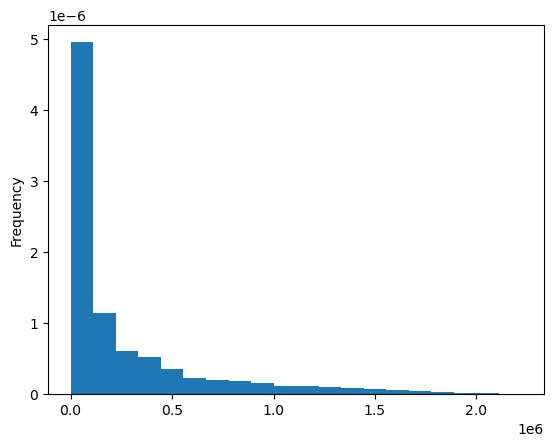

In [10]:
vendas['total'].plot(
    kind='hist',
    density=True,
    bins=20,
    log=False

)

plt.show()

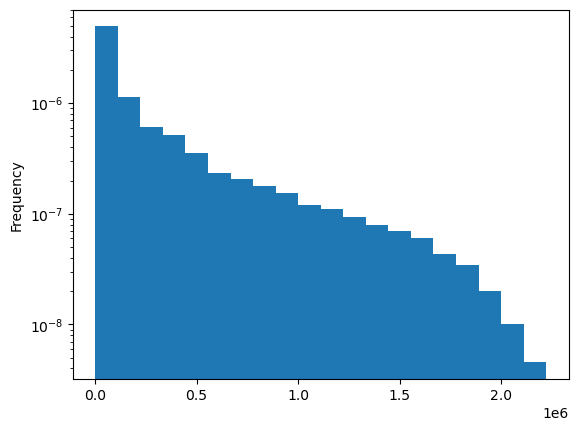

In [11]:
vendas['total'].plot(
    kind='hist',
    density=True,
    bins=20,
    log=True

)

plt.show()

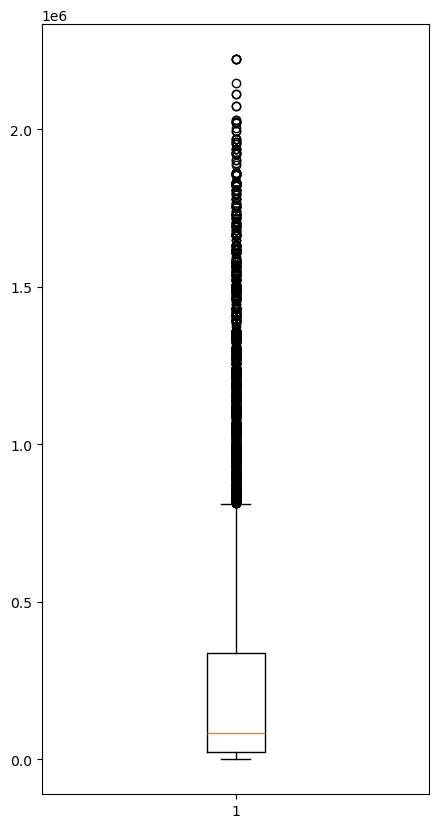

In [12]:
plt.figure(figsize=(5,10))

plt.boxplot(vendas['total'])

plt.show()